# Beyond the Quasiparticle Approximation: Lattice Heat Capacity of Strongly Anharmonic Solids

This notebook reproduces the anlaysis and figures for PbTe presented in the manuscript.

### File load

In [19]:
from ase.io import read
import numpy as np

atoms = read('POSCAR')
n_atoms = len(atoms)
masses = atoms.get_masses()  # in amu
cell = atoms.get_cell()      # lattice vectors
positions = atoms.get_positions() # Cartesian coordinates
sc_dims = np.array([4, 4, 4])
kB = 8.617333262e-5      # Boltzmann constant in eV/K
THz_to_eV = 0.004135667  # Conversion factor (h * 1e12)
T = 300.0                # Temperature in Kelvin

print(f"Loaded {n_atoms} atoms.")
print(f"{atoms}")

Loaded 2 atoms.
Atoms(symbols='PbTe', pbc=True, cell=[[0.0, 3.239, 3.239], [3.239, 0.0, 3.239], [3.239, 3.239, 0.0]])


In [20]:
import numpy as np
from scipy.interpolate import interp1d
import os
import re

target_dir = "."  
folders = [d for d in os.listdir(target_dir) if os.path.isdir(d) and d.startswith('T')]

folders.sort(key=lambda x: int(re.findall(r'\d+', x)[0]))

results = {}

print(f"Detected temperature folders: {folders}")

for folder in folders:
    print(f"\n--- Processing Folder: {folder} ---")
    
    omega_path = os.path.join(folder, 'BTE.omega')
    spectrum_path = os.path.join(folder, 'BTE.selfeng3ph_spectrum')
    
    if not os.path.exists(omega_path) or not os.path.exists(spectrum_path):
        print(f"Skipping {folder}: Missing data files.")
        continue

    # --- 1. Load BTE.omega ---
    data_omega = np.loadtxt(omega_path) 
    Nq = data_omega.shape[0]
    num_bands = data_omega.shape[1]
    
    # Band-major flattening (rad/ps -> THz)
    w_bare = (data_omega.T).flatten() / (2 * np.pi)
    num_total_modes = len(w_bare)

    # --- 2. Load and Parse BTE.selfeng3ph_spectrum ---
    spec_data = np.genfromtxt(spectrum_path)
    pts_per_mode = len(spec_data) // num_total_modes

    d_interps = [None] * num_total_modes
    g_interps = [None] * num_total_modes

    for i in range(num_total_modes):
        q_idx = i // num_bands
        b_idx = i % num_bands
        target_mode_idx = b_idx * Nq + q_idx
        
        start = i * pts_per_mode
        end = (i + 1) * pts_per_mode
        mode_block = spec_data[start:end]
        
        w_grid = mode_block[:, 0]
        d_grid = mode_block[:, 1] / (2 * np.pi) 
        g_grid = mode_block[:, 2] / (2 * np.pi)
        
        d_interps[target_mode_idx] = interp1d(w_grid, d_grid, kind='linear', fill_value="extrapolate")
        g_interps[target_mode_idx] = interp1d(w_grid, g_grid, kind='linear', fill_value="extrapolate")

    results[folder] = {
        'w_bare': w_bare,
        'd_interps': d_interps,
        'g_interps': g_interps,
        'Nq': Nq,
        'num_bands': num_bands
    }
    print(f"Done: {folder} loaded successfully.")

Detected temperature folders: ['T50', 'T100', 'T150', 'T200', 'T250', 'T300']

--- Processing Folder: T50 ---
Done: T50 loaded successfully.

--- Processing Folder: T100 ---
Done: T100 loaded successfully.

--- Processing Folder: T150 ---
Done: T150 loaded successfully.

--- Processing Folder: T200 ---
Done: T200 loaded successfully.

--- Processing Folder: T250 ---
Done: T250 loaded successfully.

--- Processing Folder: T300 ---
Done: T300 loaded successfully.


In [21]:
import numpy as np
from scipy.interpolate import interp1d

# Load BTE.qpoints to get degeneracies
q_data = np.genfromtxt('BTE.qpoints')
# Column 2 (index 2) is the degeneracy
degeneracies = q_data[:, 2] 
Nq_irr = len(degeneracies) # the number of qpoints in irreducible wedge
Nq_total = np.sum(degeneracies) # the number of qpoints in whole BZ
q_coords = q_data[:, 3:6]

print(f"Number of irreducible q-points: {Nq_irr}")
print(f"Total q-points in full BZ (Sum of weights): {Nq_total}")

Number of irreducible q-points: 455
Total q-points in full BZ (Sum of weights): 15625.0


### Data verification

In [22]:
target_temp = 'T300'

if target_temp in results:
    data = results[target_temp]
    w_bare = data['w_bare']
    d_interps = data['d_interps']
    g_interps = data['g_interps']
    Nq_irr = data['Nq']
    num_bands = data['num_bands']
    
    num_total_modes = len(w_bare)
    
    print(f"Showing results for: {target_temp}")
    print("-" * 100)

    for i in range(num_total_modes):
        w_qs = w_bare[i]

        q_irr_idx = i % Nq_irr
        band_irr_idx = i // Nq_irr
        
        weight = degeneracies[q_irr_idx]
        d_val = d_interps[i](w_qs)
        g_val = abs(g_interps[i](w_qs))
        q_coords_test = q_coords[q_irr_idx]

        print(f"i = {i}, q_irr = {q_irr_idx+1}, band_irr = {band_irr_idx+1}, weight = {weight}, "
              f"w_ha = {w_qs:.4f} THz, {w_qs*(2 * np.pi):.4e} rad/ps, "
              f"delta = {d_val:.4f}, gamma = {g_val:.4f}, {q_coords_test}")

else:
    print(f"Error: {target_temp} not found. Please check your results dictionary.")

Showing results for: T300
----------------------------------------------------------------------------------------------------
i = 0, q_irr = 1, band_irr = 1, weight = 1.0, w_ha = 0.0000 THz, 0.0000e+00 rad/ps, delta = 0.0000, gamma = 0.0000, [0. 0. 0.]
i = 1, q_irr = 2, band_irr = 1, weight = 8.0, w_ha = 0.2482 THz, 1.5595e+00 rad/ps, delta = -0.0127, gamma = 0.0018, [0.04 0.   0.  ]
i = 2, q_irr = 3, band_irr = 1, weight = 8.0, w_ha = 0.4728 THz, 2.9709e+00 rad/ps, delta = -0.0252, gamma = 0.0062, [0.08 0.   0.  ]
i = 3, q_irr = 4, band_irr = 1, weight = 8.0, w_ha = 0.6702 THz, 4.2111e+00 rad/ps, delta = -0.0339, gamma = 0.0100, [0.12 0.   0.  ]
i = 4, q_irr = 5, band_irr = 1, weight = 8.0, w_ha = 0.8478 THz, 5.3269e+00 rad/ps, delta = -0.0400, gamma = 0.0115, [0.16 0.   0.  ]
i = 5, q_irr = 6, band_irr = 1, weight = 8.0, w_ha = 1.0118 THz, 6.3570e+00 rad/ps, delta = -0.0447, gamma = 0.0128, [0.2 0.  0. ]
i = 6, q_irr = 7, band_irr = 1, weight = 8.0, w_ha = 1.1648 THz, 7.3186e+00 rad

### Coefficent for LQPA

In [23]:
import numpy as np
import pandas as pd

# Settings
temps = ["T50", "T100", "T150", "T200", "T250", "T300"]

exclude_zero_freq = True

results_a = [] 

# Loop over temperatures
for target_temp in temps:

    if target_temp not in results:
        print(f"{target_temp} not found, skipping")
        continue

    data = results[target_temp]

    w_bare = data["w_bare"]
    d_interps = data["d_interps"]
    g_interps = data["g_interps"]
    Nq_irr = data["Nq"]

    omega_list = []
    gamma_list = []
    weight_list = []

    # collect data
    for i in range(len(w_bare)):

        w_qs = w_bare[i]

        if exclude_zero_freq and abs(w_qs) < 1e-5:
            continue

        q_irr_idx = i % Nq_irr

        W = degeneracies[q_irr_idx]

        gamma = abs(float(g_interps[i](w_qs)))

        omega_list.append(w_qs)
        gamma_list.append(gamma)
        weight_list.append(W)

    omega = np.array(omega_list)
    gamma = np.array(gamma_list)
    W = np.array(weight_list)

    # weighted linear fit: Γ = a ω
    numerator = np.sum(W * omega * gamma)
    denominator = np.sum(W * omega**2)

    a = numerator / denominator

    # optional diagnostics
    gamma_mean = np.average(gamma, weights=W)
    omega_mean = np.average(omega, weights=W)

    results_a.append({
        "T": target_temp,
        "a": a,
        "gamma_mean": gamma_mean,
        "omega_mean": omega_mean,
        "n_modes": len(omega)
    })

    print(f"{target_temp}: a = {a:.6f}")

# Save results
df = pd.DataFrame(results_a)

df.to_csv("gamma_linear_fit_vs_temperature.csv", index=False)

print("\nSaved to gamma_linear_fit_vs_temperature.csv")

T50: a = 0.004098
T100: a = 0.007232
T150: a = 0.009976
T200: a = 0.012351
T250: a = 0.014444
T300: a = 0.016319

Saved to gamma_linear_fit_vs_temperature.csv


### Comparison of linewidths between LQPA and QPA at 300 K

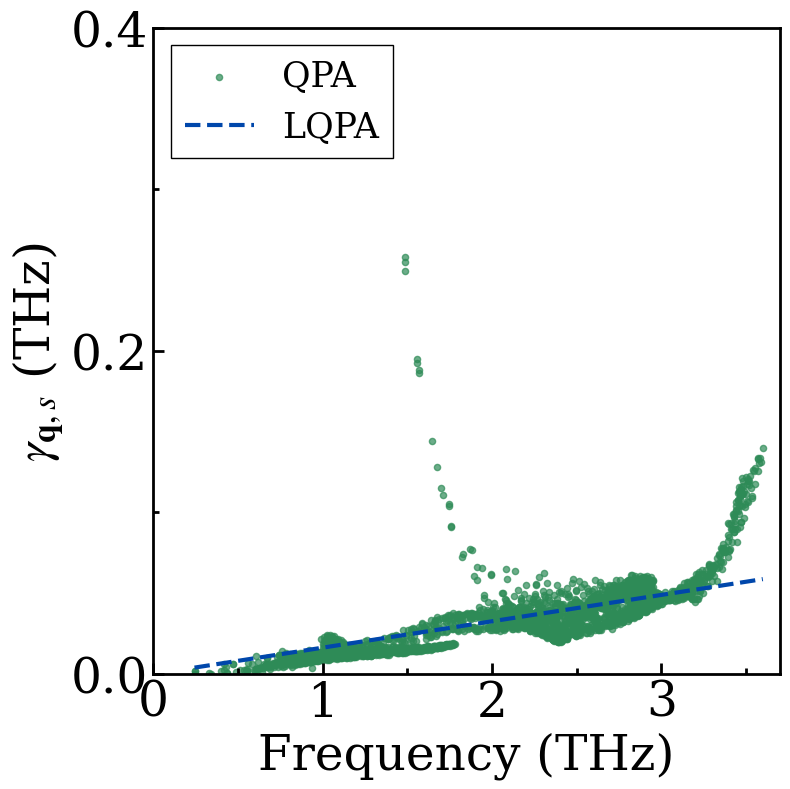

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

gamma_vals = []
freq_vals = []

for i in range(len(w_bare)):
    w_qs = w_bare[i]

    if w_qs < 1e-5:
        continue

    gamma = abs(float(g_interps[i](w_qs)))

    freq_vals.append(w_qs)
    gamma_vals.append(gamma)

plt.figure(figsize=(8, 8))
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.scatter(freq_vals, gamma_vals, s=20, label="QPA", color='#2E8B57', alpha=0.7)
plt.gca().xaxis.set_major_locator(MultipleLocator(1.0))

plt.minorticks_on()
plt.gca().xaxis.set_minor_locator(AutoMinorLocator(2))
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(2))
a = 0.016319
x_line = np.linspace(min(freq_vals), max(freq_vals), 100)
y_line = a * x_line

plt.plot(x_line, y_line, color='#0047AB', linestyle="--", linewidth=3.0, label="LQPA")
plt.xticks(fontsize=35)
plt.yticks([0, 0.2, 0.4], fontsize=35)
plt.xlim(0, 3.7)
plt.ylim(0, 0.4)
plt.xlabel("Frequency (THz)", fontsize=35)
plt.ylabel("$\gamma_{\mathbf{q},s}$ (THz)", fontsize=35)
plt.legend(loc='upper left', fontsize=25, edgecolor='black', fancybox=False, framealpha=1)

for spine in plt.gca().spines.values():
    spine.set_zorder(10)
    spine.set_linewidth(2.0)

plt.tick_params(axis='both', which='major', width=2.0, length=8, direction='in', zorder=11)
plt.tick_params(axis='both', which='minor', width=2.0, length=4, direction='in', zorder=11)
plt.grid(False)

plt.tight_layout()
plt.show()

### Harmonic heat capacity

In [25]:
import numpy as np
import pandas as pd
import os
import re

# --- Constants & Unit Conversions ---
KB = 8.617333262e-5        # Boltzmann constant in eV/K
THZ_TO_EV = 0.004135667    # Conversion factor (h * 1e12) to eV
EV_TO_J = 1.60218e-19      # 1 eV in Joules
NA = 6.02214e23            # Avogadro's number

target_dir = "."  
folders = [d for d in os.listdir(target_dir) if os.path.isdir(d) and d.startswith('T')]
folders.sort(key=lambda x: int(re.findall(r'\d+', x)[0]))

harmonic_summary = []
output_dir = "mode_resolved_harmonic"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for folder in folders:
    temp_val = float(re.findall(r'\d+', folder)[0])
    
    omega_path = os.path.join(folder, 'BTE.omega')
    if not os.path.exists(omega_path):
        continue

    # Load BTE.omega
    data_omega = np.loadtxt(omega_path)
    nq_irr = data_omega.shape[0]
    num_bands = data_omega.shape[1]
    
    # Frequency in THz
    w_bare = (data_omega.T).flatten() / (2 * np.pi)
    num_total_modes = len(w_bare)

    total_cv_harmonic = 0.0
    cv_list = []

    for i in range(num_total_modes):
        q_idx = i % nq_irr
        weight = degeneracies[q_idx]
        w_qs = w_bare[i]

        if w_qs <= 1e-6:
            mode_cv = 0.0
        else:
            x = (w_qs * THZ_TO_EV) / (KB * temp_val)
            if x < 50:
                exp_x = np.exp(x)
                mode_cv = KB * (x**2) * exp_x / (exp_x - 1)**2
            else:
                mode_cv = 0.0
        
        total_cv_harmonic += mode_cv * weight
        cv_list.append(mode_cv)

    # Unit Conversion for Total Cv
    cv_per_cell = total_cv_harmonic / Nq_total
    cv_j_mol = cv_per_cell * EV_TO_J * NA
    
    # --- Save Mode-Resolved Data ---
    df_mode_resolved = pd.DataFrame({
        'Mode_Index': np.arange(num_total_modes),
        'Frequency_THz': w_bare,
        'Cv_Contribution_eV_K': cv_list
    })
    
    csv_name = f"mode_resolved_harmonic_{folder}.csv"
    csv_path = os.path.join(output_dir, csv_name)
    df_mode_resolved.to_csv(csv_path, index=False)
    
    harmonic_summary.append({
        'Temperature': temp_val,
        'Folder': folder,
        'Cv_J_mol_K': cv_j_mol,
        'CSV_Path': csv_path
    })
    

df_summary = pd.DataFrame(harmonic_summary)
df_sorted = df_summary.sort_values('Temperature')
temperatures = df_sorted['Temperature'].values
cv_harmonic = df_sorted['Cv_J_mol_K'].values

print(df_summary[['Temperature', 'Cv_J_mol_K']])

   Temperature  Cv_J_mol_K
0         50.0   36.229877
1        100.0   45.674663
2        150.0   47.908048
3        200.0   48.740544
4        250.0   49.137386
5        300.0   49.357117


## 1. Linear quasi-particle approximation (LQPA)

In [26]:
import numpy as np
import pandas as pd
import os
import re

# --- Constants & Setup ---
KB = 8.617333262e-5        
THZ_TO_EV = 0.004135667    
EV_TO_J = 1.60218e-19      
NA = 6.02214e23            

# Frequency shift is zero
DELTA_FIXED = 0.0          

try:
    df_fit = pd.read_csv("gamma_linear_fit_vs_temperature.csv")
    a_map = dict(zip(df_fit['T'], df_fit['a']))
except FileNotFoundError:
    raise FileNotFoundError("NO gamma_linear_fit_vs_temperature.csv")

output_dir = "norm_mode_resolved_linear"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

anharmonic_summary = []

for folder in folders:
    temp_match = re.search(r'T\d+', folder)
    if not temp_match: 
        continue
    temp_key = temp_match.group()
    
    if temp_key not in a_map:
        raise ValueError(f"CRITICAL ERROR: '{temp_key}'")
    
    a_val = a_map[temp_key]
    temp_val = float(re.findall(r'\d+', temp_key)[0])
    
    if folder in results:
        w_bare = results[folder]['w_bare']
        nq_irr = results[folder]['Nq']
    else:
        data_omega = np.loadtxt(os.path.join(folder, 'BTE.omega'))
        nq_irr = data_omega.shape[0]
        w_bare = (data_omega.T).flatten() / (2 * np.pi)

    num_total_modes = len(w_bare)
    total_cv_anharmonic = 0.0
    cv_list = []


    for i in range(num_total_modes):
        q_idx = i % nq_irr
        weight = degeneracies[q_idx]
        w_qs = w_bare[i]

        if w_qs < 1e-10:
            mode_cv_integral = 0.0
        else:
            gamma_dynamic = a_val * w_qs
            
            dw = gamma_dynamic / 10.0
            w_min = max(0.001, w_qs + DELTA_FIXED - 100 * gamma_dynamic)
            w_max = w_qs + DELTA_FIXED + 100 * gamma_dynamic
            local_grid = np.arange(w_min, w_max, dw)
            
            mode_integral = 0.0
            g_list = []
            
            for w in local_grid:
                denom = (w - w_qs - DELTA_FIXED)**2 + gamma_dynamic**2
                b_w = (1.0 / np.pi) * (gamma_dynamic / denom)
                g_w = (w / w_qs) * b_w
                g_list.append(g_w)
                
            g_array = np.array(g_list)
            mode_area = np.sum(g_array) * dw
            g_norm_array = g_array / mode_area

            for w, g_norm in zip(local_grid, g_norm_array):
                x = (w * THZ_TO_EV) / (KB * temp_val)
                if x < 50:
                    cv_kernel = KB * (x**2) * np.exp(x) / (np.exp(x) - 1.0)**2
                    mode_integral += g_norm * cv_kernel * dw
            
            mode_cv_integral = mode_integral

        total_cv_anharmonic += mode_cv_integral * weight
        cv_list.append(mode_cv_integral)

    cv_per_cell = total_cv_anharmonic / Nq_total
    cv_j_mol = cv_per_cell * EV_TO_J * NA
    
    df_mode = pd.DataFrame({
        'Mode_Index': np.arange(num_total_modes),
        'Frequency_THz': w_bare,
        'Cv_Anharmonic_eV_K': cv_list
    })
    
    csv_name = f"mode_resolved_anharmonic_{temp_key}.csv"
    df_mode.to_csv(os.path.join(output_dir, csv_name), index=False)
    
    anharmonic_summary.append({
        'Temperature': temp_val,
        'Cv_Anharmonic_J_mol_K': cv_j_mol
    })

df_anharmonic_summary = pd.DataFrame(anharmonic_summary).sort_values('Temperature')
df_anharmonic_sorted = df_anharmonic_summary.sort_values('Temperature')
temperatures = df_anharmonic_sorted['Temperature'].values
cv_anharmonic = df_anharmonic_sorted['Cv_Anharmonic_J_mol_K'].values
print(df_anharmonic_summary)

   Temperature  Cv_Anharmonic_J_mol_K
0         50.0              36.207966
1        100.0              45.640369
2        150.0              47.874288
3        200.0              48.709571
4        250.0              49.109326
5        300.0              49.331641


## 2. Quasi-particle approximation (QPA)

In [27]:
import numpy as np
import pandas as pd
import os
import re

kB = 8.617333262e-5        
THz_to_eV = 0.004135667    
EV_TO_J = 1.60218e-19
NA = 6.02214e23

output_dir_qpa = "norm_mode_resolved_qpa"
if not os.path.exists(output_dir_qpa):
    os.makedirs(output_dir_qpa)

qpa_summary = []

for folder in folders:
    temp_val = float(re.findall(r'\d+', folder)[0])
    
    if folder not in results:
        print(f"Skipping {folder}: No pre-loaded results found.")
        continue
        
    w_bare = results[folder]['w_bare']
    d_interps = results[folder]['d_interps']
    g_interps = results[folder]['g_interps']
    Nq_irr = results[folder]['Nq']         

    num_total_modes = len(w_bare)
    total_cv_qpa = 0.0
    cv_list_qpa = []


    for i in range(num_total_modes):
        q_idx = i % Nq_irr
        weight = degeneracies[q_idx]
        w_qs = w_bare[i]

        if w_qs < 1e-10:
            mode_integral = 0.0
        else:
            d_val = d_interps[i](w_qs)
            g_val = abs(g_interps[i](w_qs))

            g_floor = max(g_val, 1e-4) 
            dw = g_floor / 10.0 
            w_min = max(0.001, w_qs + d_val - 100 * g_floor)
            w_max = w_qs + d_val + 100 * g_floor
            local_grid = np.arange(w_min, w_max, dw)
            
            mode_integral = 0.0
            g_list = []
            for w in local_grid:
                # b_w (Spectral function)
                denom = (w - w_qs - d_val)**2 + g_val**2
                b_w = (1.0 / np.pi) * (g_val / denom)
                # g_w (Spectral Density)
                g_w = (w / w_qs) * b_w
                g_list.append(g_w)
            g_array = np.array(g_list)

            mode_area = np.sum(g_array) * dw
            g_norm_array = g_array / mode_area
            
            for w, g_norm in zip(local_grid, g_norm_array):
                x = (w * THz_to_eV) / (kB * temp_val)
                if x < 50:
                    cv_kernel = kB * (x**2) * np.exp(x) / (np.exp(x) - 1.0)**2
                    mode_integral += g_norm * cv_kernel * dw
        
        total_cv_qpa += mode_integral * weight
        cv_list_qpa.append(mode_integral)

    cv_per_cell = total_cv_qpa / Nq_total
    cv_j_mol = cv_per_cell * EV_TO_J * NA
    
    df_mode = pd.DataFrame({
        'Mode_Index': np.arange(num_total_modes),
        'Frequency_THz': w_bare,
        'Cv_QPA_eV_K': cv_list_qpa
    })
    
    csv_name = f"mode_resolved_qpa_{folder}.csv"
    df_mode.to_csv(os.path.join(output_dir_qpa, csv_name), index=False)
    
    qpa_summary.append({
        'Temperature': temp_val,
        'Cv_QPA_J_mol_K': cv_j_mol
    })

df_qpa_summary = pd.DataFrame(qpa_summary).sort_values('Temperature')
df_qpa_sorted = df_qpa_summary.sort_values('Temperature')
temperatures = df_qpa_sorted['Temperature'].values
cv_qpa = df_qpa_sorted['Cv_QPA_J_mol_K'].values

print(df_qpa_summary)

   Temperature  Cv_QPA_J_mol_K
0         50.0       36.416817
1        100.0       45.758899
2        150.0       47.951345
3        200.0       48.764987
4        250.0       49.151776
5        300.0       49.365537


## 3. Beyond quasi-particle approximation (BQPA)

In [28]:
import numpy as np
import pandas as pd
import os
import re

# --- Constants ---
kB = 8.617333262e-5        
THz_to_eV = 0.004135667    
EV_TO_J = 1.60218e-19
NA = 6.02214e23

output_dir_bqpa = "norm_mode_resolved_bqpa"
if not os.path.exists(output_dir_bqpa):
    os.makedirs(output_dir_bqpa)

bqpa_summary = []

for folder in folders:
    
    T = float(re.findall(r'\d+', folder)[0])
    
    if folder not in results:
        continue
    
    w_bare = results[folder]['w_bare']
    d_interps = results[folder]['d_interps']
    g_interps = results[folder]['g_interps']
    Nq_irr = results[folder]['Nq']

    num_total_modes = len(w_bare)
    
    spectrum_path = os.path.join(folder, 'BTE.selfeng3ph_spectrum')
    spec_data = np.genfromtxt(spectrum_path)

    total_cv_full = 0.0
    frequencies_bqpa = []
    cv_contributions_bqpa = []

    global_w_min = spec_data[:, 0].min()
    global_w_max = spec_data[:, 0].max()

    for i in range(num_total_modes):

        q_irr_idx = i % Nq_irr
        weight = degeneracies[q_irr_idx]

        w_qs = w_bare[i]

        if w_qs < 1e-10:
            continue

        g_ref = abs(g_interps[i](w_qs))
        g_floor = max(g_ref, 1e-4)

        dw = g_floor / 10.0

        center = w_qs + d_interps[i](w_qs)

        w_min = max(global_w_min, center - 100 * g_floor)

        w_max = min(global_w_max, center + 100 * g_floor)

        w_grid = np.arange(w_min, w_max, dw)

        d_ws = d_interps[i](w_grid)
        g_ws = np.abs(g_interps[i](w_grid))

        g_ws_safe = np.where(g_ws < 1e-8, 1e-8, g_ws)

        denoms = (w_grid - w_qs - d_ws)**2 + g_ws_safe**2

        b_ws = (1 / np.pi) * (g_ws_safe / denoms)

        g_w = (w_grid / w_qs) * b_ws

        mode_area = np.trapz(g_w, w_grid)

        if mode_area < 1e-14:
            continue

        g_w_norm = g_w / mode_area

        x = (w_grid * THz_to_eV) / (kB * T)

        cv_kernels = np.zeros_like(x)

        m_zero = (x < 1e-7)
        m_finite = (x >= 1e-7) & (x < 50)

        cv_kernels[m_zero] = kB

        cv_kernels[m_finite] = (kB * (x[m_finite]**2 * np.exp(x[m_finite])) / (np.exp(x[m_finite]) - 1)**2)

        mode_integral = np.trapz(g_w_norm * cv_kernels, w_grid)
        total_cv_weighted = mode_integral * weight
        total_cv_full += total_cv_weighted

        frequencies_bqpa.append(w_qs)
        cv_contributions_bqpa.append(mode_integral)

    cv_per_cell = total_cv_full / Nq_total

    cv_j_mol = cv_per_cell * EV_TO_J * NA

    df_mode = pd.DataFrame({
        'Frequency_THz': frequencies_bqpa,
        'Cv_Contribution_eV_K': cv_contributions_bqpa
    })

    csv_name = f"mode_resolved_bqpa_{folder}.csv"

    df_mode.to_csv(os.path.join(output_dir_bqpa,
                                csv_name),
                   index=False)

    bqpa_summary.append({
        'Temperature': T,
        'Cv_J_mol_K': cv_j_mol
    })


df_bqpa_summary = pd.DataFrame(bqpa_summary).sort_values('Temperature')
df_bqpa_sorted = df_bqpa_summary.sort_values('Temperature')
temperatures = df_bqpa_sorted['Temperature'].values
cv_bqpa = df_bqpa_sorted['Cv_J_mol_K'].values

print(df_bqpa_summary)

   Temperature  Cv_J_mol_K
0         50.0   36.346448
1        100.0   45.685008
2        150.0   47.894479
3        200.0   48.722212
4        250.0   49.118762
5        300.0   49.339952


## Plot

/var/folders/8s/1wbk7ft168n0hgr946kyvykr0000gn/T/ipykernel_74427/2172410972.py:29: RuntimeWarning: invalid value encountered in divide
  cv_harmonic = kB * (x_ref**2) * np.exp(x_ref) / (np.exp(x_ref) - 1)**2


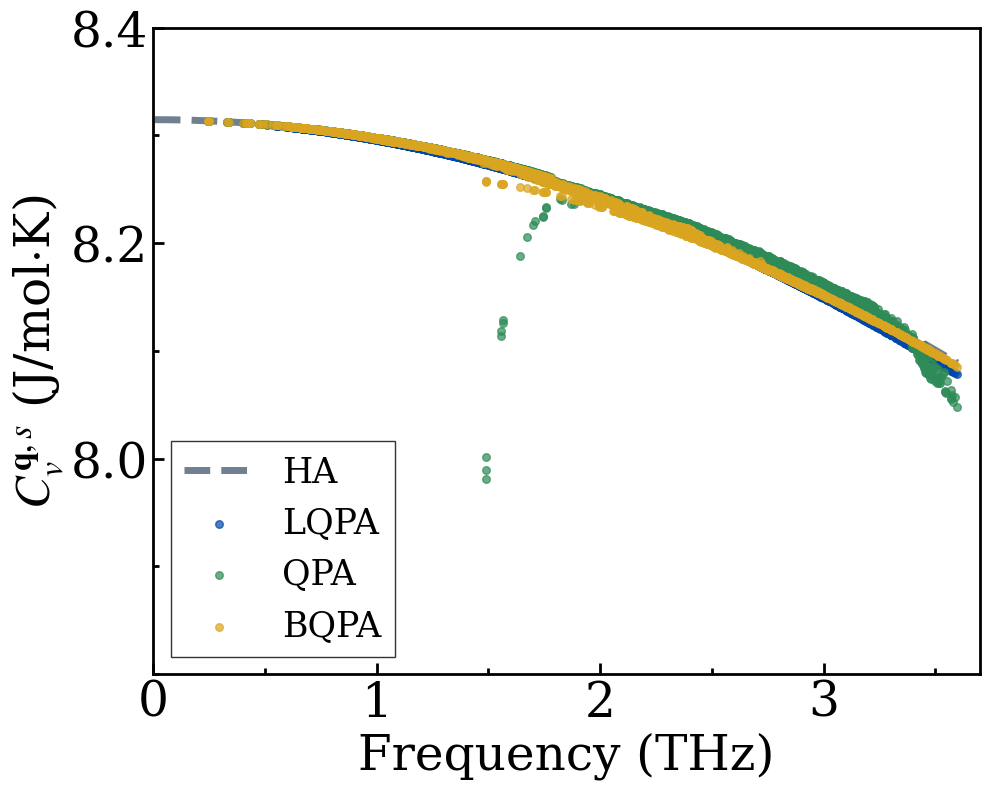

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

kB = 8.617333262e-5
THz_to_eV = 0.004135667
Unit_conv = 1.60218e-19 * 6.02214e23  # eV/K -> J/mol·K
T = 300
target_temp = "T300"

dirs = {
    "har": "mode_resolved_harmonic",
    "anh": "norm_mode_resolved_linear",
    "qpa": "norm_mode_resolved_qpa",
    "bqpa": "norm_mode_resolved_bqpa"
}

plt.figure(figsize=(10, 8))

try:
    # 1. Harmonic Reference 
    har_path = os.path.join(dirs["har"], f"mode_resolved_harmonic_{target_temp}.csv")
    if os.path.exists(har_path):
        df_har = pd.read_csv(har_path)
        w_ref = np.linspace(df_har['Frequency_THz'].min(), df_har['Frequency_THz'].max(), 500)
        x_ref = (w_ref * THz_to_eV) / (kB * T)
        cv_harmonic = kB * (x_ref**2) * np.exp(x_ref) / (np.exp(x_ref) - 1)**2
        plt.plot(w_ref, cv_harmonic * Unit_conv, 
                 color='SlateGrey', linestyle='--', linewidth=5, label='HA', zorder=1)

    # LQPA
    anh_path = os.path.join(dirs["anh"], f"mode_resolved_anharmonic_{target_temp}.csv")
    if os.path.exists(anh_path):
        df_anh = pd.read_csv(anh_path)
        plt.scatter(df_anh['Frequency_THz'], df_anh['Cv_Anharmonic_eV_K'] * Unit_conv, 
                    alpha=0.7, s=30, color='#0047AB', label='LQPA', zorder=2)

    # QPA
    qpa_path = os.path.join(dirs["qpa"], f"mode_resolved_qpa_{target_temp}.csv")
    if os.path.exists(qpa_path):
        df_qpa = pd.read_csv(qpa_path)
        plt.scatter(df_qpa['Frequency_THz'], df_qpa['Cv_QPA_eV_K'] * Unit_conv, 
                    alpha=0.7, s=30, color='#2E8B57', label='QPA', zorder=3)

    # BQPA
    bqpa_path = os.path.join(dirs["bqpa"], f"mode_resolved_bqpa_{target_temp}.csv")
    if os.path.exists(bqpa_path):
        df_bqpa = pd.read_csv(bqpa_path)
        plt.scatter(df_bqpa['Frequency_THz'], df_bqpa['Cv_Contribution_eV_K'] * Unit_conv, 
                    alpha=0.7, s=30, color='#DAA520', label='BQPA', zorder=4)

except Exception as e:
    print(f"error: {e}")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.xlabel('Frequency (THz)', fontsize=35)
plt.ylabel('$C_{v}^{\mathbf{q},s}$ (J/mol$\cdot$K)', fontsize=35)
plt.xticks(fontsize=35)
plt.yticks([8, 8.2, 8.4], fontsize=35)

plt.legend(loc='best', fontsize=25, edgecolor='black', fancybox=False)

plt.xlim(0, 3.7) 
plt.ylim(7.8, 8.4)

plt.grid(False)
plt.tick_params(axis='both', which='major', width=2.0, length=8, direction='in')
plt.minorticks_on()
plt.gca().xaxis.set_minor_locator(AutoMinorLocator(2))
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(2))
plt.gca().xaxis.set_major_locator(MultipleLocator(1.0))
plt.tick_params(axis='both', which='minor', width=2.0, length=4, direction='in')

for spine in plt.gca().spines.values():
    spine.set_linewidth(2.0)

plt.tight_layout()
plt.show()

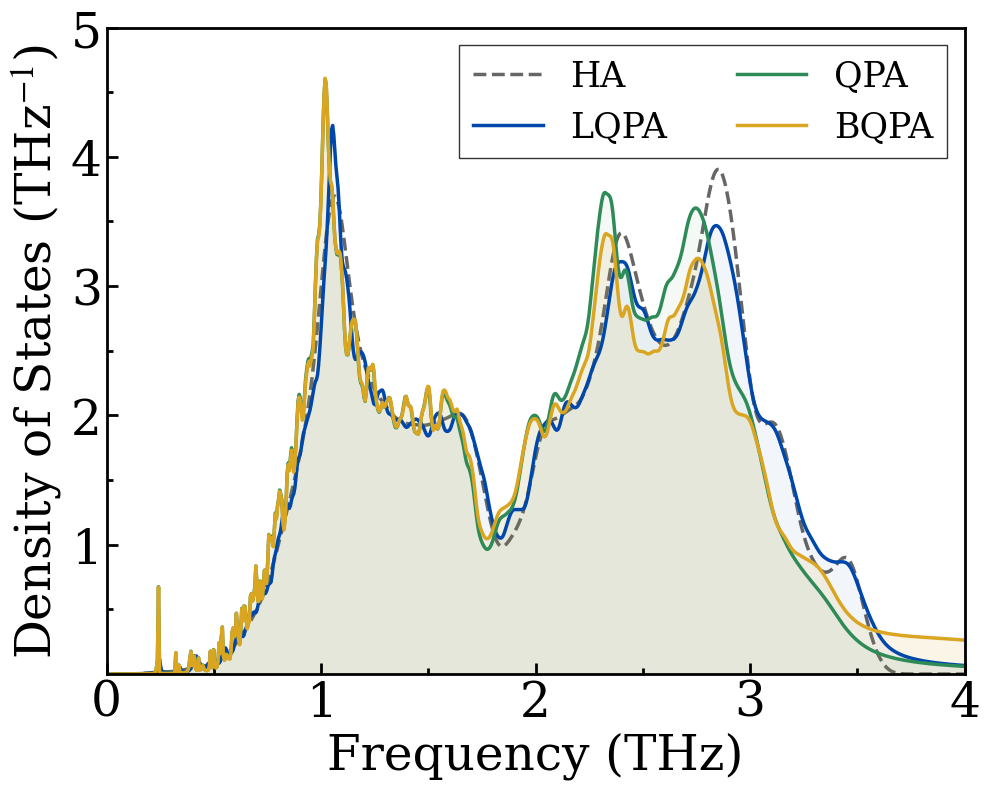

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import re

target_folder = 'T300' 

if target_folder not in results:
    found = False
    for f in results.keys():
        if '300' in f:
            target_folder = f
            found = True
            break
    if not found:
        raise ValueError(f"CRITICAL ERROR")

w_bare = results[target_folder]['w_bare']
d_interps = results[target_folder]['d_interps']
g_interps = results[target_folder]['g_interps']
nq_irr = results[target_folder]['Nq']
temp_val = float(re.findall(r'\d+', target_folder)[0])

if target_folder in a_map:
    a_val = a_map[target_folder]
elif 300 in a_map:
    a_val = a_map[300]
else:
    a_val = list(a_map.values())[0] 

num_total_modes = len(w_bare)
Nq_total = np.sum(degeneracies)

# --- 1. Setup Global Energy Axis ---
w_max_limit = np.max(w_bare) * 1.4
energy_axis = np.linspace(0, w_max_limit, 1000)

# --- 2. DOS Calculation Containers ---
dos_harmonic = np.zeros_like(energy_axis)
dos_method1 = np.zeros_like(energy_axis)  
dos_method2 = np.zeros_like(energy_axis)  
dos_method3 = np.zeros_like(energy_axis)  

# --- 3. Compute Each Method ---
# Harmonic DOS (Gaussian Broadening)
sigma = 0.05
for i, w_qs in enumerate(w_bare):
    q_irr_idx = i % nq_irr
    weight = degeneracies[q_irr_idx]
    diff = energy_axis - w_qs
    dos_harmonic += weight * np.exp(-0.5 * (diff / sigma)**2) / (sigma * np.sqrt(2 * np.pi))


# LQPA
for i, w_qs in enumerate(w_bare):
    q_irr_idx = i % nq_irr
    weight = degeneracies[q_irr_idx]
    if w_qs < 1e-10: continue
        
    gamma_dynamic = a_val * w_qs
    dw_local = gamma_dynamic / 10.0
    w_min = max(0.001, w_qs + DELTA_FIXED - 100 * gamma_dynamic)
    w_max = w_qs + DELTA_FIXED + 100 * gamma_dynamic
    local_grid = np.arange(w_min, w_max, dw_local)
    
    denom_local = (local_grid - w_qs - DELTA_FIXED)**2 + gamma_dynamic**2
    b_w_local = (1.0 / np.pi) * (gamma_dynamic / denom_local)
    g_w_local = (local_grid / w_qs) * b_w_local
    mode_area = np.sum(g_w_local) * dw_local
    
    denom_global = (energy_axis - w_qs - DELTA_FIXED)**2 + gamma_dynamic**2
    b_w_global = (1.0 / np.pi) * (gamma_dynamic / denom_global)
    g_w_global = (energy_axis / w_qs) * b_w_global
    
    dos_method1 += weight * (g_w_global / mode_area)


# QPA
for i, w_qs in enumerate(w_bare):
    q_irr_idx = i % nq_irr
    weight = degeneracies[q_irr_idx]
    if w_qs < 1e-10: continue

    d_val = d_interps[i](w_qs)
    g_val = abs(g_interps[i](w_qs))
    g_floor = max(g_val, 1e-4) 
    
    dw_local = g_floor / 10.0 
    w_min = max(0.001, w_qs + d_val - 100 * g_floor)
    w_max = w_qs + d_val + 100 * g_floor
    local_grid = np.arange(w_min, w_max, dw_local)
    
    denom_local = (local_grid - w_qs - d_val)**2 + g_val**2
    b_w_local = (1.0 / np.pi) * (g_val / denom_local)
    g_w_local = (local_grid / w_qs) * b_w_local
    mode_area = np.sum(g_w_local) * dw_local
    
    denom_global = (energy_axis - w_qs - d_val)**2 + g_val**2
    b_w_global = (1.0 / np.pi) * (g_val / denom_global)
    g_w_global = (energy_axis / w_qs) * b_w_global
    
    dos_method2 += weight * (g_w_global / mode_area)

# BQPA
spectrum_path = os.path.join(target_folder, 'BTE.selfeng3ph_spectrum')
if os.path.exists(spectrum_path):
    spec_data = np.genfromtxt(spectrum_path)
    global_w_min = spec_data[:, 0].min()
    global_w_max = spec_data[:, 0].max()
else:
    global_w_min, global_w_max = 0.0, w_max_limit

for i, w_qs in enumerate(w_bare):
    q_irr_idx = i % nq_irr
    weight = degeneracies[q_irr_idx]
    if w_qs < 1e-10: continue

    g_ref = abs(g_interps[i](w_qs))
    g_floor = max(g_ref, 1e-4)
    dw_local = g_floor / 10.0
    center = w_qs + d_interps[i](w_qs)
    
    w_min = max(global_w_min, center - 100 * g_floor)
    w_max = min(global_w_max, center + 100 * g_floor)
    w_grid_local = np.arange(w_min, w_max, dw_local)
    

    d_ws_local = d_interps[i](w_grid_local)
    g_ws_local = np.abs(g_interps[i](w_grid_local))
    g_ws_safe_local = np.where(g_ws_local < 1e-8, 1e-8, g_ws_local)
    
    denom_local = (w_grid_local - w_qs - d_ws_local)**2 + g_ws_safe_local**2
    b_ws_local = (1.0 / np.pi) * (g_ws_safe_local / denom_local)
    g_w_local = (w_grid_local / w_qs) * b_ws_local
    
    mode_area = np.trapz(g_w_local, w_grid_local)
    if mode_area < 1e-14: continue
    d_ws_global = d_interps[i](energy_axis)
    g_ws_global = np.abs(g_interps[i](energy_axis))
    g_ws_safe_global = np.where(g_ws_global < 1e-8, 1e-8, g_ws_global)
    
    denom_global = (energy_axis - w_qs - d_ws_global)**2 + g_ws_safe_global**2
    b_ws_global = (1.0 / np.pi) * (g_ws_safe_global / denom_global)
    g_w_global = (energy_axis / w_qs) * b_ws_global
    dos_method3 += weight * (g_w_global / mode_area)

dos_harmonic /= Nq_total
dos_method1 /= Nq_total
dos_method2 /= Nq_total
dos_method3 /= Nq_total

plt.figure(figsize=(10, 8))
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'stix'

plt.plot(energy_axis, dos_harmonic, color='#666666', linestyle='--', linewidth=2.5, label='HA', zorder=1)
plt.plot(energy_axis, dos_method1, color='#0047AB', linestyle='-', linewidth=2.5, label='LQPA', zorder=2)
plt.fill_between(energy_axis, 0, dos_method1, color='#0047AB', alpha=0.05)
plt.plot(energy_axis, dos_method2, color='#2E8B57', linestyle='-', linewidth=2.5, label='QPA', zorder=3)
plt.fill_between(energy_axis, 0, dos_method2, color='#2E8B57', alpha=0.05)
plt.plot(energy_axis, dos_method3, color='#DAA520', linestyle='-', linewidth=2.5, label='BQPA', zorder=4)
plt.fill_between(energy_axis, 0, dos_method3, color='#DAA520', alpha=0.1)

plt.xlabel('Frequency (THz)', fontsize=35)
plt.ylabel('Density of States (THz$^{-1}$)', fontsize=35)
plt.xticks([0, 1, 2, 3, 4,], fontsize=35)
plt.yticks([1, 2, 3, 4, 5], fontsize=35)
plt.xlim(0, 4)
plt.ylim(0, 5)

plt.legend(loc='upper right', fontsize=25, edgecolor='black', fancybox=False, ncol=2)
plt.grid(False)

plt.tick_params(axis='both', which='major', width=2.0, length=8, direction='in')
plt.minorticks_on()
plt.gca().xaxis.set_minor_locator(AutoMinorLocator(2))
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(2))
plt.tick_params(axis='both', which='minor', width=2.0, length=4, direction='in')

for spine in plt.gca().spines.values():
    spine.set_linewidth(2.0)
    spine.set_zorder(10)

plt.tight_layout()
plt.show()

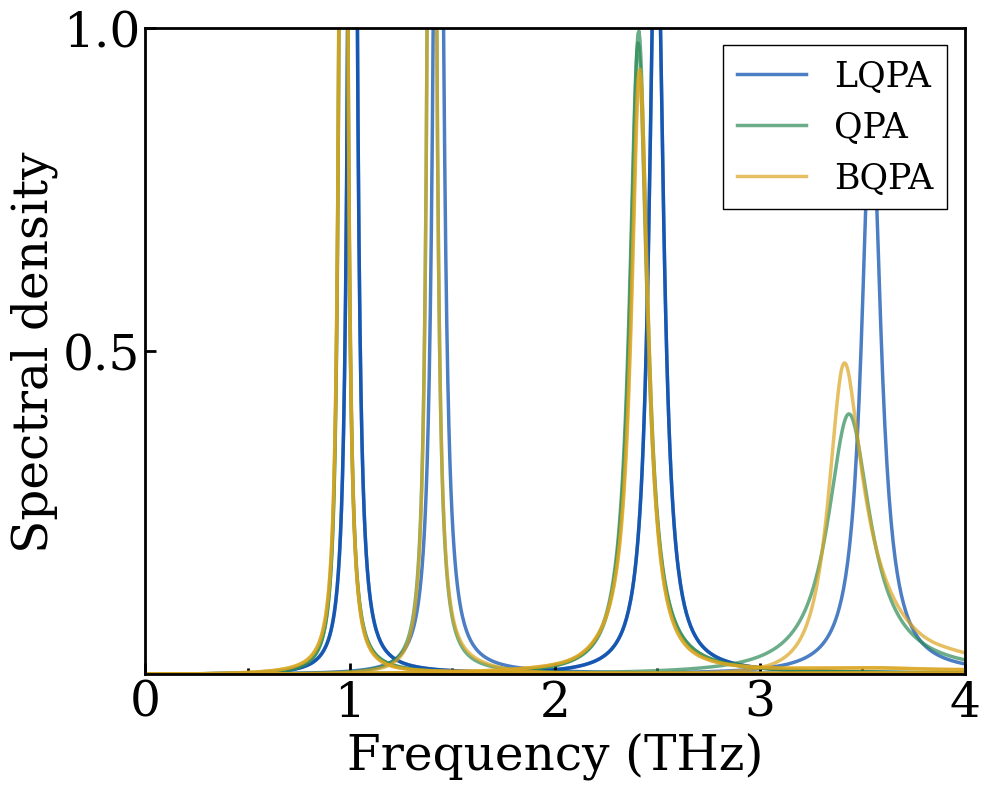

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

if 'DELTA_FIXED' not in globals():
    DELTA_FIXED = 0.0

# --- 1. Target q-point selection ---
target_q = np.array([0.2, 0, 0])
distances = np.linalg.norm(q_coords - target_q, axis=1)
target_q_idx = np.argmin(distances)

plt.figure(figsize=(10, 8))

color_m1 = '#0047AB' 
color_m2 = '#2E8B57' 
color_m3 = '#DAA520' 

band_idx = 0
for i in range(len(w_bare)):
    if (i % nq_irr) == target_q_idx:
        w_qs = w_bare[i]
        if w_qs < 1e-10: continue

        # Method 1: LQPA
        gamma_dynamic = a_val * w_qs
        dw_local = gamma_dynamic / 10.0
        w_min = max(0.001, w_qs + DELTA_FIXED - 100 * gamma_dynamic)
        w_max = w_qs + DELTA_FIXED + 100 * gamma_dynamic
        local_grid = np.arange(w_min, w_max, dw_local)
        
        denom_local = (local_grid - w_qs - DELTA_FIXED)**2 + gamma_dynamic**2
        b_w_local = (1.0 / np.pi) * (gamma_dynamic / denom_local)
        g_w_local = (local_grid / w_qs) * b_w_local
        mode_area_m1 = np.sum(g_w_local) * dw_local
        
        denom_global = (energy_axis - w_qs - DELTA_FIXED)**2 + gamma_dynamic**2
        b_w_global = (1.0 / np.pi) * (gamma_dynamic / denom_global)
        g_w_global = (energy_axis / w_qs) * b_w_global
        spectral_m1 = (1.0 / (2.0 * np.pi)) * g_w_global / mode_area_m1
        
        plt.plot(energy_axis, spectral_m1, color=color_m1, linewidth=2.5, zorder=1, alpha=0.7,
                 label='LQPA' if band_idx == 0 else "")

        # Method 2: QPA
        d_val = d_interps[i](w_qs)
        g_val = abs(g_interps[i](w_qs))
        g_floor = max(g_val, 1e-4) 
        
        dw_local = g_floor / 10.0 
        w_min = max(0.001, w_qs + d_val - 100 * g_floor)
        w_max = w_qs + d_val + 100 * g_floor
        local_grid = np.arange(w_min, w_max, dw_local)
        
        denom_local = (local_grid - w_qs - d_val)**2 + g_val**2
        b_w_local = (1.0 / np.pi) * (g_val / denom_local)
        g_w_local = (local_grid / w_qs) * b_w_local
        mode_area_m2 = np.sum(g_w_local) * dw_local
        
        denom_global = (energy_axis - w_qs - d_val)**2 + g_val**2
        b_w_global = (1.0 / np.pi) * (g_val / denom_global)
        g_w_global = (energy_axis / w_qs) * b_w_global
        spectral_m2 = (1.0 / (2.0 * np.pi)) * g_w_global / mode_area_m2
        
        plt.plot(energy_axis, spectral_m2, color=color_m2, linewidth=2.5, zorder=2, alpha=0.7,
                 label='QPA' if band_idx == 0 else "")

        # Method 3: BQPA
        center = w_qs + d_interps[i](w_qs)
        w_min_bte = center - 100 * g_floor
        w_max_bte = center + 100 * g_floor
        if 'global_w_min' in locals() or 'global_w_min' in globals():
            w_min_bte = max(global_w_min, w_min_bte)
            w_max_bte = min(global_w_max, w_max_bte)
        w_grid_local = np.arange(w_min_bte, w_max_bte, dw_local)
        
        d_ws_local = d_interps[i](w_grid_local)
        g_ws_local = np.abs(g_interps[i](w_grid_local))
        g_ws_safe_local = np.where(g_ws_local < 1e-8, 1e-8, g_ws_local)
        
        denom_local = (w_grid_local - w_qs - d_ws_local)**2 + g_ws_safe_local**2
        b_ws_local = (1.0 / np.pi) * (g_ws_safe_local / denom_local)
        g_w_local = (w_grid_local / w_qs) * b_ws_local
        mode_area_m3 = np.trapz(g_w_local, w_grid_local)
        
        if mode_area_m3 > 1e-14:
            d_ws_global = d_interps[i](energy_axis)
            g_ws_global = np.abs(g_interps[i](energy_axis))
            g_ws_safe_global = np.where(g_ws_global < 1e-8, 1e-8, g_ws_global)
            
            denom_global = (energy_axis - w_qs - d_ws_global)**2 + g_ws_safe_global**2
            b_ws_global = (1.0 / np.pi) * (g_ws_safe_global / denom_global)
            g_w_global = (energy_axis / w_qs) * b_ws_global
            spectral_m3 = (1.0 / (2.0 * np.pi)) * g_w_global / mode_area_m3
            
            plt.plot(energy_axis, spectral_m3, color=color_m3, linewidth=2.5, zorder=3, alpha=0.7,
                     label='BQPA' if band_idx == 0 else "")
        
        band_idx += 1

plt.xlabel('Frequency (THz)', fontsize=35)
plt.ylabel('Spectral density', fontsize=35)

plt.xlim(0, 4.0) 
plt.ylim(0, 1.0)

plt.gca().xaxis.set_major_locator(MultipleLocator(1.0))
plt.gca().xaxis.set_minor_locator(AutoMinorLocator(2))

plt.xticks(fontsize=35)
plt.yticks([0.5, 1.0], fontsize=35)

plt.legend(loc='upper right', fontsize=25, edgecolor='black', fancybox=False, framealpha=1)

for spine in plt.gca().spines.values():
    spine.set_zorder(10)
    spine.set_linewidth(2.0)

plt.tick_params(axis='both', which='major', width=2.0, length=8, direction='in', zorder=11)
plt.tick_params(axis='both', which='minor', width=2.0, length=4, direction='in', zorder=11)
plt.grid(False)

plt.tight_layout()
plt.show()